In [ ]:
!pip install node2vec
!pip install pyswarms
!pip install kagglehub

In [ ]:
import pandas as pd
import numpy as np
import json
import networkx as nx
import matplotlib.pyplot as plt

from node2vec import Node2Vec
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import pyswarms as ps
import kagglehub

In [ ]:
path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")

print("Dataset path:", path)

100%|██████████| 4.07G/4.07G [00:35<00:00, 125MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/yelp-dataset/yelp-dataset/versions/4


In [ ]:
file = path + "/yelp_academic_dataset_review.json"

df = pd.read_json(file, lines=True, nrows=50000)

print(df.shape)

df.head()

(50000, 9)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [ ]:
df = df[['user_id','business_id','date']]

df = df.sample(30000, random_state=42)

df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.to_period('M')

df.head()

,user_id,business_id,date,month
33553,sfLl4UdQFRDvxUV0ohrPHQ,SZU9c8V2GuREDN5KgyHFJw,2017-09-12 05:23:08,2017-09
9427,9i_k73BOrjTiC7fgGcJ70w,r43DrfYAbAgifsYyNkljZw,2015-03-05 17:49:44,2015-03
199,Lc5U0qetusunJZ0NgNO_Iw,Y2rYM2crYfTC25y6iquPgw,2015-08-30 16:34:23,2015-08
12447,QO373fqoVVYBqF5cuC7ekA,2er_V-oAd7IbQ5YTY56r7A,2018-04-04 17:43:10,2018-04
39489,_fcUO5z6T3p3f06T6Zjo_w,FrjN8iGJBqRWhLW2E1brAg,2017-08-19 23:28:20,2017-08


In [ ]:
months = sorted(df["month"].unique())

window = 3

In [ ]:
graphs = {}

for i in range(len(months) - window + 1):

    window_months = months[i:i+window]

    subset = df[df["month"].isin(window_months)]

    G = nx.Graph()

    for business, g in subset.groupby("business_id"):

        users = list(g["user_id"])

        if len(users) > 15:
            users = users[:15]

        for a in range(len(users)):
            for b in range(a+1, len(users)):
                G.add_edge(users[a], users[b])

    if G.number_of_nodes() >= 40 and G.number_of_edges() >= 80:

        key = f"{window_months[0]}-{window_months[-1]}"

        graphs[key] = G

print("Snapshots:", len(graphs))

Snapshots: 91


In [ ]:
def get_embeddings(G):

    node2vec = Node2Vec(
        G,
        dimensions=16,
        walk_length=10,
        num_walks=20,
        workers=2
    )

    model = node2vec.fit(window=5, min_count=1)

    nodes = list(G.nodes())

    X = np.array([model.wv[node] for node in nodes])

    return nodes, X

In [ ]:
def estimate_k(X, k_min=2, k_max=10):

    best_k = k_min
    best_score = -1

    for k in range(k_min, k_max+1):

        kmeans = KMeans(n_clusters=k, random_state=42)

        labels = kmeans.fit_predict(X)

        score = silhouette_score(X, labels)

        if score > best_score:

            best_score = score
            best_k = k

    return best_k

In [ ]:
def run_pso_clustering(X, nodes, k):

    dim = X.shape[1]

    dimensions = k * dim

    def fitness(particles):

        scores = []

        for particle in particles:

            centers = particle.reshape(k, dim)

            dist = pairwise_distances(X, centers)

            scores.append(np.sum(np.min(dist, axis=1)))

        return np.array(scores)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=10,
        dimensions=dimensions,
        options={'c1':0.5,'c2':0.3,'w':0.9}
    )

    best_cost, best_pos = optimizer.optimize(fitness, iters=20)

    centers = best_pos.reshape(k, dim)

    dist = pairwise_distances(X, centers)

    labels = np.argmin(dist, axis=1)

    communities = {}

    for node, label in zip(nodes, labels):

        communities[node] = int(label)

    return communities

In [ ]:
dynamic_communities = {}

for month, G in graphs.items():

    print("Processing:", month)

    nodes, X = get_embeddings(G)

    k = estimate_k(X)

    print("Estimated communities:", k)

    communities = run_pso_clustering(X, nodes, k)

    dynamic_communities[month] = communities

Processing: 2009-11-2010-03


Computing transition probabilities:   0%|          | 0/104 [00:00<?, ?it/s]

2026-04-05 15:01:05,290 - gensim.models.word2vec - INFO - collecting all words and their counts
2026-04-05 15:01:05,291 - gensim.models.word2vec - INFO - PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-04-05 15:01:05,302 - gensim.models.word2vec - INFO - collected 104 word types from a corpus of 20800 raw words and 2080 sentences
2026-04-05 15:01:05,304 - gensim.models.word2vec - INFO - Creating a fresh vocabulary
2026-04-05 15:01:05,308 - gensim.utils - INFO - Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 104 unique words (100.00% of original 104, drops 0)', 'datetime': '2026-04-05T15:01:05.308389', 'gensim': '4.4.0', 'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'platform': 'Linux-6.6.113+-x86_64-with-glibc2.35', 'event': 'prepare_vocab'}
2026-04-05 15:01:05,311 - gensim.utils - INFO - Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 20800 word corpus (100.00% of original 20800, drops 0)', 'datetime': '2026-04-0

Estimated communities: 10


pyswarms.single.global_best: 100%|██████████|20/20, best_cost=324
2026-04-05 15:01:05,645 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 323.84440009091384, best pos: [-0.7384756  -0.13197971 -0.47128522  0.70393489 -0.38404786  0.32839385
  0.01570148  0.11186768  0.0158721   0.51196209  0.17210484  0.07834391
 -0.33887472  0.89916992 -0.32672453  0.06961204 -0.49141564 -0.08618257
  0.89357884  0.17479436 -0.00429057 -0.28536801  0.19478671  0.44488404
  0.63474834 -0.07270726 -0.59901714  0.14068607 -0.4671105  -0.85676625
  0.08681725 -0.76713316  0.06341245  0.19501603  0.14948766 -0.20084279
  0.11405362 -0.69752525  0.34078404 -0.09528979  0.30492746  0.38017575
 -0.69755222  0.07351808  0.32138828 -0.28292222  0.27466514  0.41265127
 -0.39750941 -0.1247863   0.1683098   0.34935413  0.7902542   0.50768101
  0.1144652   0.03089642 -0.49790925  0.6881006   0.36466667  0.18455779
  0.52459087  0.90591032 -0.50878856  0.02164359 -0.27048643 -0.05992389
  0

...

Processing: 2018-08-2018-10


Computing transition probabilities:   0%|          | 0/258 [00:00<?, ?it/s]

2026-04-05 15:03:58,298 - gensim.models.word2vec - INFO - collecting all words and their counts
2026-04-05 15:03:58,300 - gensim.models.word2vec - INFO - PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-04-05 15:03:58,313 - gensim.models.word2vec - INFO - collected 258 word types from a corpus of 51600 raw words and 5160 sentences
2026-04-05 15:03:58,314 - gensim.models.word2vec - INFO - Creating a fresh vocabulary
2026-04-05 15:03:58,316 - gensim.utils - INFO - Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 258 unique words (100.00% of original 258, drops 0)', 'datetime': '2026-04-05T15:03:58.316520', 'gensim': '4.4.0', 'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'platform': 'Linux-6.6.113+-x86_64-with-glibc2.35', 'event': 'prepare_vocab'}
2026-04-05 15:03:58,318 - gensim.utils - INFO - Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 51600 word corpus (100.00% of original 51600, drops 0)', 'datetime': '2026-04-0

Estimated communities: 10


pyswarms.single.global_best: 100%|██████████|20/20, best_cost=960
2026-04-05 15:03:59,395 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 959.6336719062659, best pos: [ 0.89136605  0.84586941 -0.00584485 -0.16169444  0.21747989 -0.46071717
  0.84513679  0.36738321  0.78900087  1.05442445  0.48378818  1.01964354
 -0.82842756  0.67319963 -0.03684544 -1.74098325  0.56375446 -0.4207765
  0.96586313 -0.7816063   0.62955145 -0.27895343  1.21046153  0.36144654
 -0.07361157  0.78097591  0.88535418 -0.25786565  0.61002637 -0.65689893
  0.6714421   0.52778955  0.64178491  0.20536545 -0.21183309  0.2183823
 -0.39531221  0.29595683  0.12472652 -0.09172762  0.8429126   0.21063968
  0.50270338  0.64419733  0.61658521  0.08626419  0.06801607 -0.32255389
 -0.02297718  0.34581167 -0.17664932  0.32838727 -0.53431613  1.00210154
 -0.25053046  0.61183156 -0.1277422  -0.13066601 -0.0369274  -0.65429252
  0.49916221 -0.24278143  1.00853922  0.34195911  0.15617379  0.69119993
  0.90

In [ ]:
import networkx.algorithms.community as nx_comm

modularity_scores = {}

for month, G in graphs.items():

    partition = dynamic_communities[month]

    comm_dict = {}

    for node, c in partition.items():

        comm_dict.setdefault(c, []).append(node)

    mod = nx_comm.modularity(G, comm_dict.values())

    modularity_scores[month] = mod

    print(month, "Modularity:", mod)

2009-11-2010-03 Modularity: 0.5894556811421772
2010-01-2010-05 Modularity: 0.7317253426498254
2010-03-2010-07 Modularity: 0.622770083102493
2010-05-2010-08 Modularity: 0.7462783553875236
2010-12-2011-02 Modularity: 0.7682379349046016
2011-01-2011-03 Modularity: 0.7546082555316165
2011-02-2011-04 Modularity: 0.6852076124567473
2011-03-2011-05 Modularity: 0.6339900084833632
2011-05-2011-07 Modularity: 0.7612005739795918
2011-06-2011-08 Modularity: 0.5277683883180098
2011-07-2011-09 Modularity: 0.6046972508011469
2011-08-2011-10 Modularity: 0.766953125
2011-12-2012-02 Modularity: 0.5471200648999459
2012-01-2012-03 Modularity: 0.6320529513888888
2012-02-2012-04 Modularity: 0.48760869565217396
2012-03-2012-05 Modularity: 0.5610642850904008
2012-04-2012-06 Modularity: 0.6024274955936549
2012-05-2012-07 Modularity: 0.44460197437513127
2012-06-2012-08 Modularity: 0.2994706994328923
2012-07-2012-09 Modularity: 0.6406797744246304
2012-10-2012-12 Modularity: 0.7358799048751486
2012-11-2013-01 Mod

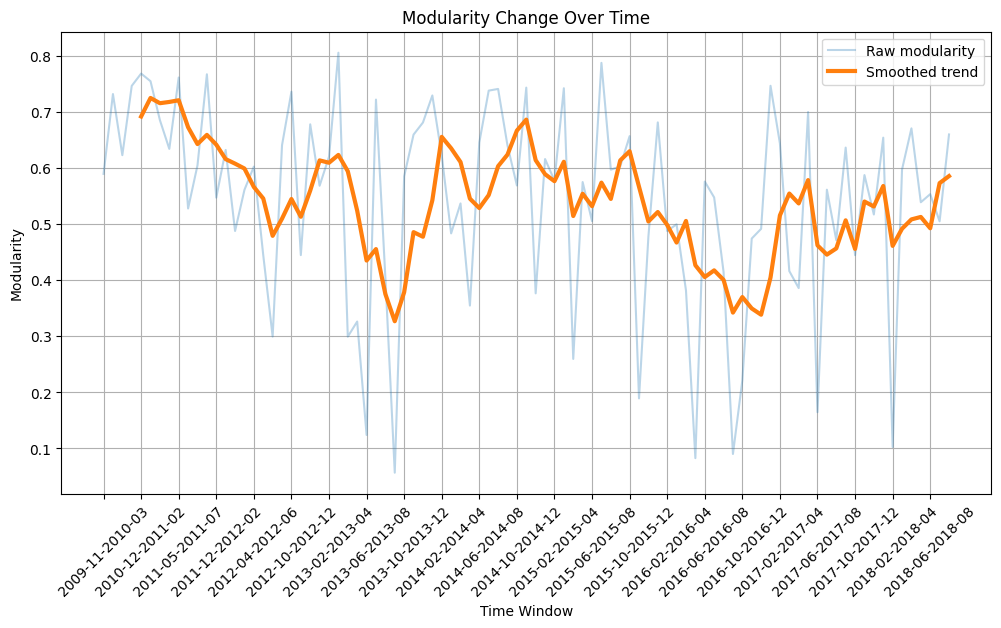

In [ ]:
months = list(modularity_scores.keys())

scores = np.array(list(modularity_scores.values()))

window = 5

smooth_scores = np.convolve(scores, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,6))

plt.plot(months, scores, alpha=0.3, label="Raw modularity")

plt.plot(months[window-1:], smooth_scores, linewidth=3, label="Smoothed trend")

plt.xticks(months[::4], rotation=45)

plt.xlabel("Time Window")

plt.ylabel("Modularity")

plt.title("Modularity Change Over Time")

plt.legend()

plt.grid()

plt.show()

In [ ]:
# ── INTERACTIVE D3 VISUALIZATION — runs directly inside Colab ────────────────
import json
import pandas as pd
from IPython.display import HTML, display

# ── 1. Select top-3 temporally-separated snapshots ───────────────────────────
def parse_start(m):
    parts = m.split('-')
    return pd.Period(f"{parts[0]}-{parts[1]}", freq='M')

sorted_mod = sorted(modularity_scores.items(), key=lambda x: x[1], reverse=True)

selected = []
for month, score in sorted_mod:
    if not selected:
        selected.append((month, score))
    else:
        starts  = [parse_start(s[0]) for s in selected]
        cand    = parse_start(month)
        min_gap = min(abs((cand - s).n) for s in starts)
        if min_gap >= 6:
            selected.append((month, score))
    if len(selected) == 3:
        break

selected_sorted = sorted(selected, key=lambda x: x[0])
labels_map      = ['t-1', 't', 't+1']
top3            = {labels_map[i]: selected_sorted[i] for i in range(3)}

print("Selected snapshots:")
for lbl, (month, score) in top3.items():
    G = graphs[month]
    print(f"  {lbl}  window={month}  mod={score:.4f}  nodes={G.number_of_nodes()}  edges={G.number_of_edges()}")

# ── 2. Build ALL_GRAPHS JSON ──────────────────────────────────────────────────
MAX_NODES = 120

def build_graph_json(lbl, month, score):
    G         = graphs[month]
    partition = dynamic_communities[month]
    valid_nodes = [n for n in G.nodes() if n in partition]

    if len(valid_nodes) > MAX_NODES:
        rng         = __import__('numpy').random.default_rng(42)
        valid_nodes = list(rng.choice(valid_nodes, MAX_NODES, replace=False))

    node_set  = set(valid_nodes)
    node_list = [{"id": n, "name": n[:12], "comm": partition[n]} for n in valid_nodes]
    n_comms   = len(set(partition[n] for n in valid_nodes))
    link_list = [
        {"source": u, "target": v, "intra": partition.get(u) == partition.get(v)}
        for u, v in G.edges()
        if u in node_set and v in node_set and u != v
    ]
    return {"label": lbl, "window": month, "mod": round(score, 4),
            "nComms": n_comms, "nodes": node_list, "links": link_list}

all_graphs_data = {lbl: build_graph_json(lbl, month, score)
                   for lbl, (month, score) in top3.items()}
all_graphs_json = json.dumps(all_graphs_data)

# ── 3. Render HTML + D3 inline ────────────────────────────────────────────────
html = f"""
<div id="viz-root" style="font-family:-apple-system,sans-serif;background:#f7f8fa;padding:0;border-radius:10px;overflow:hidden;border:1px solid #e2e4e8;">

<div style="background:#fff;border-bottom:1px solid #e2e4e8;padding:12px 16px;display:flex;align-items:center;gap:12px;">
  <b style="font-size:15px;">Dynamic Community Visualization</b>
  <span style="font-size:11px;color:#888;">Yelp Co-occurrence Network — Top 3 Modularity Snapshots</span>
</div>

<div id="vz-tabs" style="display:flex;gap:8px;padding:12px 16px 0;background:#f7f8fa;flex-wrap:wrap;"></div>

<div style="display:flex;gap:16px;flex-wrap:wrap;padding:8px 16px;background:#fff;border-bottom:1px solid #e2e4e8;font-size:12px;color:#666;margin-top:10px;">
  <span>Label: <b id="vz-label">—</b></span>
  <span>Window: <b id="vz-window">—</b></span>
  <span>Modularity: <b id="vz-mod">—</b></span>
  <span>Nodes: <b id="vz-nodes">—</b></span>
  <span>Edges: <b id="vz-edges">—</b></span>
  <span>Communities: <b id="vz-comms">—</b></span>
</div>

<div style="position:relative;background:#fff;margin:12px 16px 0;border:1px solid #e2e4e8;border-radius:8px;overflow:hidden;">
  <svg id="vz-svg" style="display:block;width:100%;"></svg>
  <div id="vz-tip" style="position:absolute;pointer-events:none;background:#fff;border:1px solid #ccd0db;border-radius:8px;padding:8px 12px;font-size:12px;display:none;z-index:10;white-space:nowrap;box-shadow:0 4px 16px rgba(0,0,0,.12);"></div>
</div>

<p style="font-size:11px;color:#aaa;padding:6px 16px;">🖱 Drag nodes · Scroll to zoom · Hover for info · Same color = same community</p>
<div id="vz-legend" style="display:flex;flex-wrap:wrap;gap:8px;padding:8px 16px 14px;"></div>

</div>

<script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.9.0/d3.min.js"></script>
<script>
(function() {{

const PALETTE = ['#7F77DD','#1D9E75','#D85A30','#D4537E','#378ADD',
                 '#639922','#BA7517','#E24B4A','#0F6E56','#993556',
                 '#534AB7','#3B6D11','#993C1D','#185FA5','#854F0B'];

const ALL_GRAPHS = {all_graphs_json};
const KEYS       = Object.keys(ALL_GRAPHS);
const LMAP       = {{'t-1':'⬅ t−1','t':'★ t (Peak)','t+1':'t+1 ➡'}};
let   sim        = null;
let   curKey     = KEYS[1] || KEYS[0];

// ── Tabs ──────────────────────────────────────────────────────────────────────
const tabBar = document.getElementById('vz-tabs');
KEYS.forEach(k => {{
  const d   = ALL_GRAPHS[k];
  const btn = document.createElement('button');
  btn.id    = 'vzbtn_' + k.replace(/[^a-z0-9]/g,'_');
  btn.style.cssText = 'padding:7px 14px;border:1.5px solid #d0d3da;border-radius:8px;background:#fff;color:#555;font-size:12px;font-weight:500;cursor:pointer;white-space:nowrap;transition:all .2s;';
  btn.innerHTML = `${{LMAP[k]||k}}&nbsp; <span style="opacity:.7">${{d.window}}</span>&nbsp; <span style="background:#fef9ec;border:1px solid #f0c040;border-radius:5px;padding:2px 7px;font-size:11px;color:#7a5c00;font-weight:600;">mod ${{d.mod}}</span>`;
  btn.onclick = () => showGraph(k);
  tabBar.appendChild(btn);
}});

function setActive(key) {{
  KEYS.forEach(k => {{
    const b = document.getElementById('vzbtn_' + k.replace(/[^a-z0-9]/g,'_'));
    if (b) b.style.cssText = k === key
      ? 'padding:7px 14px;border:1.5px solid #1e40af;border-radius:8px;background:#1e40af;color:#fff;font-size:12px;font-weight:500;cursor:pointer;white-space:nowrap;'
      : 'padding:7px 14px;border:1.5px solid #d0d3da;border-radius:8px;background:#fff;color:#555;font-size:12px;font-weight:500;cursor:pointer;white-space:nowrap;transition:all .2s;';
  }});
}}

function showGraph(key) {{ curKey = key; setActive(key); render(ALL_GRAPHS[key]); }}

// ── Render ────────────────────────────────────────────────────────────────────
function render(data) {{
  if (sim) sim.stop();
  const svgEl = document.getElementById('vz-svg');
  const W     = Math.max(svgEl.parentElement.clientWidth || 700, 500);
  const H     = Math.max(Math.round(W * 0.60), 400);
  const svg   = d3.select('#vz-svg');
  svg.selectAll('*').remove();
  svg.attr('viewBox', `0 0 ${{W}} ${{H}}`).attr('height', H);

  document.getElementById('vz-label').textContent  = data.label;
  document.getElementById('vz-window').textContent = data.window;
  document.getElementById('vz-mod').textContent    = data.mod;
  document.getElementById('vz-nodes').textContent  = data.nodes.length;
  document.getElementById('vz-edges').textContent  = data.links.length;
  document.getElementById('vz-comms').textContent  = data.nComms;

  // Legend
  const leg = document.getElementById('vz-legend');
  leg.innerHTML = '';
  for (let c = 0; c < data.nComms; c++) {{
    leg.innerHTML += `<div style="display:flex;align-items:center;gap:5px;font-size:11px;color:#555;background:#f7f8fa;padding:3px 10px;border-radius:20px;border:1px solid #e2e4e8;">
      <div style="width:10px;height:10px;border-radius:50%;background:${{PALETTE[c%PALETTE.length]}};flex-shrink:0;"></div>Community ${{c+1}}</div>`;
  }}

  const nodeMap = {{}};
  data.nodes.forEach(n => nodeMap[n.id] = n);
  const links = data.links
    .filter(l => nodeMap[l.source] && nodeMap[l.target] && l.source !== l.target)
    .map(l => ({{ source: nodeMap[l.source], target: nodeMap[l.target], intra: l.intra }}));

  const g = svg.append('g');
  svg.call(d3.zoom().scaleExtent([0.1, 8]).on('zoom', e => g.attr('transform', e.transform)));

  const hullG = g.append('g');
  const edgeG = g.append('g');
  const nodeG = g.append('g');

  const edgeSel = edgeG.selectAll('line').data(links).join('line')
    .attr('stroke',       d => d.intra ? 'rgba(40,40,40,0.11)' : 'rgba(40,40,40,0.04)')
    .attr('stroke-width', d => d.intra ? 1.4 : 0.8);

  const R = Math.min(W,H) * 0.28;
  const centers = {{}};
  for (let c = 0; c < data.nComms; c++) {{
    const a = 2*Math.PI*c/data.nComms - Math.PI/2;
    centers[c] = {{ x: W/2 + R*Math.cos(a), y: H/2 + R*Math.sin(a) }};
  }}

  let rs = 77;
  const sr = () => {{ rs = Math.imul(rs^rs>>>16,0x45d9f3b)>>>0; return rs/4294967296; }};
  data.nodes.forEach(n => {{
    const cc = centers[n.comm]||{{x:W/2,y:H/2}};
    n.x=cc.x+(sr()-.5)*60; n.y=cc.y+(sr()-.5)*60;
    delete n.vx; delete n.vy; delete n.fx; delete n.fy;
  }});

  const nodeSel = nodeG.selectAll('g').data(data.nodes).join('g').attr('cursor','pointer');
  nodeSel.call(d3.drag()
    .on('start',(e,d)=>{{ if(!e.active) sim.alphaTarget(0.3).restart(); d.fx=d.x; d.fy=d.y; }})
    .on('drag', (e,d)=>{{ d.fx=e.x; d.fy=e.y; }})
    .on('end',  (e,d)=>{{ if(!e.active) sim.alphaTarget(0); d.fx=null; d.fy=null; }}));

  nodeSel.append('circle').attr('r',16).attr('fill',d=>PALETTE[d.comm%PALETTE.length]).attr('opacity',0.14);
  nodeSel.append('circle').attr('r', 9).attr('fill',d=>PALETTE[d.comm%PALETTE.length])
    .attr('stroke','#fff').attr('stroke-width',1.5).attr('opacity',0.95);
  nodeSel.append('text').text(d=>d.name)
    .attr('dy','2.4em').attr('text-anchor','middle')
    .attr('font-size','9px').attr('fill','#444').attr('pointer-events','none');

  const tip = document.getElementById('vz-tip');
  nodeSel
    .on('mouseover', function(e,d) {{
      const r  = document.getElementById('vz-svg').parentElement.getBoundingClientRect();
      const nr = this.getBoundingClientRect();
      tip.innerHTML = `<b style="font-size:13px;display:block;margin-bottom:2px;">${{d.name}}</b>Community ${{d.comm+1}} | ${{data.label}}<br><span style="color:#888;font-size:11px;">${{d.id}}</span>`;
      tip.style.display = 'block';
      tip.style.left = (nr.left - r.left + 18) + 'px';
      tip.style.top  = (nr.top  - r.top  - 10) + 'px';
    }})
    .on('mouseout', () => tip.style.display = 'none');

  function updateHulls() {{
    const byComm = {{}};
    data.nodes.forEach(n => {{ if(!byComm[n.comm]) byComm[n.comm]=[]; byComm[n.comm].push([n.x,n.y]); }});
    hullG.selectAll('path').data(Object.entries(byComm)).join('path')
      .attr('d',([c,pts]) => {{
        if(pts.length<3) return null;
        const hull=d3.polygonHull(pts); if(!hull) return null;
        const cx=d3.mean(hull,p=>p[0]), cy=d3.mean(hull,p=>p[1]);
        const exp=hull.map(([px,py])=>[cx+(px-cx)*1.45, cy+(py-cy)*1.45]);
        return 'M'+exp.map(p=>p.join(',')).join('L')+'Z';
      }})
      .attr('fill',  ([c])=>PALETTE[c%PALETTE.length]).attr('opacity',0.08)
      .attr('stroke',([c])=>PALETTE[c%PALETTE.length])
      .attr('stroke-width',1.5).attr('stroke-opacity',0.25)
      .attr('stroke-dasharray','5 4').attr('pointer-events','none');
  }}

  sim = d3.forceSimulation(data.nodes)
    .force('link',      d3.forceLink(links).id(d=>d.id).distance(d=>d.intra?34:200).strength(d=>d.intra?0.78:0.03))
    .force('charge',    d3.forceManyBody().strength(-160))
    .force('collision', d3.forceCollide(22))
    .force('cx',        d3.forceX(d=>(centers[d.comm]||{{x:W/2}}).x).strength(0.44))
    .force('cy',        d3.forceY(d=>(centers[d.comm]||{{y:H/2}}).y).strength(0.44))
    .alphaDecay(0.02)
    .on('tick',()=>{{
      edgeSel.attr('x1',d=>d.source.x).attr('y1',d=>d.source.y)
             .attr('x2',d=>d.target.x).attr('y2',d=>d.target.y);
      nodeSel.attr('transform',d=>`translate(${{d.x}},${{d.y}})`);
      updateHulls();
    }});
}}

showGraph(curKey);

}})();
</script>
"""

display(HTML(html))

Selected snapshots:
  t-1  window=2010-12-2011-02  mod=0.7682  nodes=101  edges=99
  t  window=2013-03-2013-05  mod=0.8054  nodes=208  edges=200
  t+1  window=2015-07-2015-09  mod=0.7873  nodes=695  edges=803
